# Vuelo Air Midwest 5481 — Simulación accidente (Beechcraft 1900D)

**Contenido:** simulación dividida en:
1. Carrera de despegue hasta rotación,
2. Simulación trayectoria ascensoi (u, w, q, θ),
3. Pérdida de control e impacto.

**Nota:** este notebook usa datos del informe NTSB AAR-04/01 (peso ≈ 17,700 lb; CG ≈ 45.5% MAC; elevador AND limitado ≈ 7°) y modelos simplificados donde no hay datos de acceso público con plena exactitud.

In [1]:
#carga de librerias

import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
import pandas as pd

In [2]:
# ------------------------- Parámetros físicos y del informe NTSB -------------------------
g = 9.80665
# Datos NTSB
takeoff_weight_lb = 17700.0                         # lb (NTSB reporta aprox. 17,700 lb)
takeoff_weight_kg = takeoff_weight_lb * 0.45359237
W = takeoff_weight_kg * g                           # Newtons
cg_actual_frac = 0.455                              # 45.5 % MAC (Centro de gravedad REAL identificado por NTSB)
cg_reported_frac = 0.378                            # 37.8 % MAC (Centro de gravedad CALCULADO ERRÓNEAMENTE por la aerolínea)
cg_component_min = 0.433                            # 43.3 % MAC (Valor mínimo según el MÉTODO COMPONENTE del NTSB)
elev_down_limit_deg = 7.0                           # 7° AND (Desplazamiento restringido hacia abajo)
elev_up_limit_deg = 20.0                            # ~20° ANU (Desplazamiento por diseño)

In [3]:
# Geometría aproximada Beech 1900D (valores aproximados)
S = 28.8                    # m^2 (area del plano)
b = 17.67                   # m, envergadura
c_bar = 1.5                 # m, MAC - Cuerda media aerodinámica (approx)
S_tail = 6.2                # m^2 area estabilizador horizontal (estimation)
l_tail = 5.8                # m, tail moment arm (distancia del CG al centro del estabilizador horizontal)
mass = takeoff_weight_kg
L = 17.6                    # longitud total del Beechcraft 1900D (m)
ky = 0.20 * L               # radio de giro estimado
Iyy = mass * ky**2          # fórmula general

In [4]:
# Aerodinámica básica (valores estimados)
rho0 = 1.225                                # kg/m^3 (densidad del aire, el accidente ocurrió apenas a 737 ft)
CL_alpha = 5.0                              # 1/rad (aprox)
alpha0 = np.radians(2.0)                    # El ala del Beech 1900D está instalada con incidencia positiva, por eso CL no es cero a α = 0
alpha_stall = np.radians(14.0)              # Es el ángulo de ataque aproximado de entrada en pérdida. El Beechcraft 1900D presenta stall entre 14° y 16°, depende del peso y configuración
CL_max = CL_alpha * (alpha_stall - alpha0)  # Máximo coeficiente de sustentación antes del stall
CD0 = 0.028                                 # Coeficiente de resistencia parasita del avión (fricción, piel, protuberancias)
k = 0.045                                   # Factor de resistencia inducida del avión
CL_max = 2.0                                # valor típico aproximado para avión con flaps en despegue (ajustable)

In [5]:
# Motores (PT6A approx 1279 shp each)
P_shp_each = 1279.0             # Potencia en SHP (shaft horsepower) producida por cada motor
P_each = P_shp_each * 745.7     # Convierte la potencia de shp a Watts
eta_prop = 0.80                 # Eficiencia propulsiva de la hélice
n_eng = 2                       # El Beechcraft 1900D tiene dos PT6A-67D montados en las ala
P_total = n_eng * P_each        # Potencia total disponible del avión, en Watts

In [6]:
# Coeficientes de momento (simplificados y tunables)
Cm0 = 0.02           # Momento de cabeceo intrínseco del avión cuando ángulo de ataque = 0, elevador neutral y CG en su posición nominal
Cm_alpha = -0.8      # Estabilidad en cabeceo por ángulo de ataque (per rad)
Cm_delta_e = -0.5    # Efecto del elevador en el momento de cabeceo (per rad)
Cm_cg = -1.6         # Efecto del centro de gravedad sobre el momento(tunado para reproducir demanda de elevador)

In [7]:
# Aerodinámica de la cola (efectividad)
eta_tail = 0.9        # Eficiencia de la cola horizontal
CL_alpha_tail = 3.5   # Pendiente de sustentación del estabilizador horizontal

In [8]:
# ------------------------- Coordenadas iniciales Charlotte 18R -------------------------
lat0 = 35.225061      # Cabecera 18R CLT
lon0 = -80.967428
heading_deg = 176.0   # Rumbo magnético aproximado de pista 18R

In [9]:
# Síntesis de datos

# Conversores automáticos
# ===========================================

def to_percent(value):
    """Convierte fracciones 0–1 → porcentaje"""
    try:
        if 0 < value < 1:
            return f"{value*100:.1f} %"
        return value
    except:
        return value

def rad_to_deg(value):
    """Convierte ángulos rad → grados en formato 0.00°"""
    try:
        if abs(value) < 2:   # umbral típico para ángulos pequeños
            return f"{np.degrees(value):.2f}°"
        return value
    except:
        return value


# ===========================================
# Lista depurada de parámetros esenciales
# ===========================================

parametros = [
    # --- Física básica ---
    "g",
    "takeoff_weight_lb",
    "cg_actual_frac",
    "cg_reported_frac",
    "cg_component_min",

    # --- Geometría ---
    "S",
    "b",
    "c_bar",
    "S_tail",
    "l_tail",
    "Iyy",

    # --- Aerodinámica ---
    "rho0",
    "CL_alpha",
    "alpha0",
    "alpha_stall",
    "CD0",
    "k",
    "eta_tail",
    "CL_alpha_tail",

    # --- Estabilidad longitudinal ---
    "Cm0",
    "Cm_alpha",
    "Cm_delta_e",
    "Cm_cg",

    # --- Motores ---
    "P_shp_each",
    "eta_prop",
    "n_eng"
]


# ===========================================
# Valores RAW (DEBEN EXISTIR EN TU NOTEBOOK)
# ===========================================

valores_raw = [
    g,
    takeoff_weight_lb,
    cg_actual_frac,
    cg_reported_frac,
    cg_component_min,

    S,
    b,
    c_bar,
    S_tail,
    l_tail,
    Iyy,

    rho0,
    CL_alpha,
    alpha0,
    alpha_stall,
    CD0,
    k,
    eta_tail,
    CL_alpha_tail,

    Cm0,
    Cm_alpha,
    Cm_delta_e,
    Cm_cg,

    P_shp_each,
    eta_prop,
    n_eng
]


# ===========================================
# Unidades
# ===========================================

unidades = [
    # Física básica
    "m/s²",
    "lb",
    "% MAC",
    "% MAC",
    "% MAC",

    # Geometría
    "m²",
    "m",
    "m",
    "m²",
    "m",
    "kg·m²",

    # Aerodinámica
    "kg/m³",
    "1/rad",
    "rad",
    "rad",
    "adim",
    "adim",
    "adim",
    "1/rad",

    # Estabilidad
    "adim",
    "1/rad",
    "1/rad",
    "1/fracMAC",

    # Motores
    "shp",
    "%",
    "—"
]


# ===========================================
# Descripciones breves
# ===========================================

descripciones = [
    "Gravedad estándar",
    "Peso al despegue",
    "CG real según NTSB",
    "CG reportado por aerolínea",
    "CG mínimo por método de componentes",

    "Área alar",
    "Envergadura total",
    "Cuerda media aerodinámica",
    "Área del estabilizador horizontal",
    "Brazo cola–CG",
    "Momento de inercia longitudinal",

    "Densidad aire a nivel del mar",
    "Pendiente CL vs α del ala",
    "Ángulo donde CL=0",
    "Ángulo de pérdida",
    "Arrastre parasitario",
    "Factor de arrastre inducido",
    "Eficiencia de la cola",
    "Pendiente CL vs α cola",

    "Momento base en α=0",
    "Variación del momento con α",
    "Autoridad del elevador",
    "Sensibilidad del momento al CG",

    "Potencia por motor (PT6A, shp)",
    "Eficiencia propulsiva",
    "Número de motores"
]


# ===========================================
# APLICAR CONVERSIONES
# ===========================================

valores = []
for p, v in zip(parametros, valores_raw):

    # Fracciones → %
    if ("cg" in p) or (p == "eta_prop"):
        valores.append(to_percent(v))
        continue

    # Ángulos → grados
    if p in ["alpha0", "alpha_stall"]:
        valores.append(rad_to_deg(v))
        continue

    valores.append(v)


# ===========================================
# TABLA FINAL
# ===========================================

df = pd.DataFrame({
    "Parámetro": parametros,
    "Valor": valores,
    "Unidad": unidades,
    "Descripción breve": descripciones
})

df

,Parámetro,Valor,Unidad,Descripción breve
0,g,9.80665,m/s²,Gravedad estándar
1,takeoff_weight_lb,17700.0,lb,Peso al despegue
2,cg_actual_frac,45.5 %,% MAC,CG real según NTSB
3,cg_reported_frac,37.8 %,% MAC,CG reportado por aerolínea
4,cg_component_min,43.3 %,% MAC,CG mínimo por método de componentes
5,S,28.8,m²,Área alar
6,b,17.67,m,Envergadura total
7,c_bar,1.5,m,Cuerda media aerodinámica
8,S_tail,6.2,m²,Área del estabilizador horizontal
9,l_tail,5.8,m,Brazo cola–CG


In [10]:
# ------------------------- Cálculos aerodinámicos -------------------------
def aero_CL(alpha):
    # lineal hasta stall, caída suave después
    if alpha <= alpha_stall:
        return CL_alpha * (alpha - alpha0)
    else:
        CLs = CL_alpha * (alpha_stall - alpha0)
        return CLs * max(0.2, 1 - 0.6*(alpha - alpha_stall)/np.radians(10))

def aero_CD(CL):
    return CD0 + k*CL*CL

def thrust_available(V):
    V_floor = 15.0
    T = (P_total * eta_prop) / max(V, V_floor)
    return min(T, 34000.0)

def estimated_takeoff_distance(W, rho, S, CL_max, T, V_rotate):
    """
    Estima la distancia de despegue usando:

        L = [1.44 * W^2] / [g * rho * S * CLmax * (T - D)]

    donde D se evalúa a CLmax y V_rotate.
    """
    q = 0.5 * rho * V_rotate**2
    CD_at_CLmax = CD0 + k * CL_max**2
    D = q * S * CD_at_CLmax
    L = (1.44 * W**2) / (g * rho * S * CL_max * max(T - D, 1.0))
    return L

In [11]:
# ------------------------- Algoritmo para convertir distancia → coordenadas -------------------------
def project_point(lat, lon, distance_m, heading_deg):
    R = 6378137.0
    heading = np.radians(heading_deg)

    lat_new = np.arcsin(
        np.sin(np.radians(lat)) * np.cos(distance_m / R) +
        np.cos(np.radians(lat)) * np.sin(distance_m / R) * np.cos(heading)
    )

    lon_new = np.radians(lon) + np.arctan2(
        np.sin(heading) * np.sin(distance_m / R) * np.cos(np.radians(lat)),
        np.cos(distance_m / R) - np.sin(np.radians(lat)) * np.sin(lat_new)
    )

    return np.degrees(lat_new), np.degrees(lon_new)

In [12]:
# Dataclass TO
@dataclass
class TakeoffResult:
    t: np.ndarray
    V: np.ndarray
    x: np.ndarray
    lat: np.ndarray
    lon: np.ndarray
    alt_ft: np.ndarray
    pitch_deg: np.ndarray
    heading_deg: np.ndarray
    phase: np.ndarray
    Vr_target: float
    s_rotate: float

In [13]:
# ------------------------- 1) Carrera de despegue y rotación -------------------------

def takeoff_run(Vr_target_kt=104.0,
                rho=rho0,
                flap_deg=0.0,
                lat0=lat0,
                lon0=lon0,
                heading_deg=178.0):   # rumbo pista 18R real

    dt = 0.05
    V = 0.1
    x = 0.0
    t = 0.0

    ts, xs, Vs = [], [], []
    lats, lons = [], []
    alts_ft = []
    pitchs = []
    headings = []
    phases = []

    Vr_target = Vr_target_kt * 0.514444   # Conversión kt → m/s

    while V < Vr_target and t < 120.0:

        T = thrust_available(V)

        # Alpha aproximado durante rodaje
        alpha_roll = np.radians(2.0)
        CL = aero_CL(alpha_roll)

        q = 0.5 * rho * V**2
        L = q * S * CL
        D = q * S * aero_CD(CL)
        N = W - L
        Fr = 0.03 * N

        a = (T - D - Fr) / mass

        V = max(0.1, V + a*dt)
        x += V*dt
        t += dt

        # ===== Coordenadas nuevas según desplazamiento =====
        lat, lon = project_point(lat0, lon0, x, heading_deg)

        # Altitud permanece a la elevación de la cabecera (737 ft MSL)
        alt_ft = 737.0

        # Pitch prácticamente fijo ~10° durante rodaje
        pitch_deg = 10.0

        # Heading constante alineado con pista
        heading_current = heading_deg

        # Guardados
        ts.append(t)
        xs.append(x)
        Vs.append(V)
        lats.append(lat)
        lons.append(lon)
        alts_ft.append(alt_ft)
        pitchs.append(pitch_deg)
        headings.append(heading_current)
        phases.append("TAKEOFF_ROLL")

    # ===== Comparación con distancia teórica de despegue =====
    V_rotate = Vr_target
    T_rot = thrust_available(V_rotate)
    L_teorica = estimated_takeoff_distance(W, rho, S, CL_max, T_rot, V_rotate)
    print("Distancia de despegue teórica (fórmula):", L_teorica, "m")
    print("Distancia de rotación simulada:", xs[-1], "m")


    return TakeoffResult(
        t=np.array(ts),
        V=np.array(Vs),
        x=np.array(xs),
        lat=np.array(lats),
        lon=np.array(lons),
        alt_ft=np.array(alts_ft),
        pitch_deg=np.array(pitchs),
        heading_deg=np.array(headings),
        phase=np.array(phases),
        Vr_target=Vr_target,
        s_rotate=xs[-1]
    )

In [14]:
# Dataclass CLIMB
@dataclass
class ClimbResult:
    t: np.ndarray
    V: np.ndarray
    lat: np.ndarray
    lon: np.ndarray
    alt_ft: np.ndarray
    pitch_deg: np.ndarray
    roll_deg: np.ndarray
    heading_deg: np.ndarray
    phase: np.ndarray

In [15]:
# ------------------------- 2) Ascenso y entrada en pre-pérdida -------------------------

def climb_to_pre_stall(res_to: TakeoffResult,
                       field_elev_ft: float = 740.0,
                       target_AGL_ft: float = 1150.0,   # ahora sube hasta 1150 ft AGL
                       V_target_kt: float = 139.0,
                       total_time: float = 22.0,        # de 13:46:48 a 13:47:10
                       heading_deg: float = heading_deg):

    # Estado inicial: final de Fase 1
    lat = res_to.lat[-1]
    lon = res_to.lon[-1]
    V0 = res_to.V[-1]
    t0 = res_to.t[-1]
    alt0_ft = res_to.alt_ft[-1]  # continuar exactamente donde terminó la Fase 1

    # Estado final: 1150 ft AGL
    altf_ft = field_elev_ft + target_AGL_ft
    alt0_m = alt0_ft * 0.3048
    altf_m = altf_ft * 0.3048
    climb_rate = (altf_m - alt0_m) / total_time  # m/s

    Vf = V_target_kt * 0.514444  # m/s

    dt = 0.1
    n_steps = int(total_time / dt)

    # Ángulo geométrico de ascenso (por Δh / V)
    V_mean = max(0.5 * (V0 + Vf), 1.0)
    gamma_geom = np.arcsin(np.clip(climb_rate / V_mean, -0.3, 0.3))

    # Chequeo con sin(gamma) = (T - D)/W (solo para análisis en consola)
    alpha_climb = np.radians(8.0)     # supongamos alpha ~ 8°
    CL_climb = aero_CL(alpha_climb)
    q_mean = 0.5 * rho0 * V_mean**2
    D_mean = q_mean * S * aero_CD(CL_climb)
    T_mean = thrust_available(V_mean)
    gamma_thrust = np.arcsin(np.clip((T_mean - D_mean) / W, -0.3, 0.3))

    print("Ángulo de ascenso geométrico (deg):", np.degrees(gamma_geom))
    print("Ángulo de ascenso por (T-D)/W (deg):", np.degrees(gamma_thrust))

    ts = []
    Vs = []
    lats = []
    lons = []
    alts_ft = []
    pitchs = []
    rolls = []
    headings = []
    phases = []

    t = t0
    V = V0
    alt_m = alt0_m
    lat_curr = lat
    lon_curr = lon

    for i in range(n_steps):
        frac = (i + 1) / n_steps

        # Velocidad: de V0 → Vf
        V = V0 + (Vf - V0) * frac

        # Pitch: de ~10° a ~20° (no exageramos aún)
        pitch_deg = 5.0 + 15.0 * frac   # 5° → 20°, sube desde un pitch más bajo

        # Roll ~ 0 (no hay viraje aún)
        roll_deg = 0.0

        # Altitud usando climb_rate (coherente con total_time)
        alt_m += climb_rate * dt

        # Movimiento horizontal con el ángulo de ascenso gamma_geom
        V_horizontal = V * np.cos(gamma_geom)
        distance_step = V_horizontal * dt

        lat_curr, lon_curr = project_point(lat_curr, lon_curr,
                                           distance_step, heading_deg)

        t += dt

        ts.append(t)
        Vs.append(V)
        lats.append(lat_curr)
        lons.append(lon_curr)
        alts_ft.append(alt_m / 0.3048)
        pitchs.append(pitch_deg)
        rolls.append(roll_deg)
        headings.append(heading_deg)
        phases.append("UNSTABLE_CLIMB_PRESTALL")

    return ClimbResult(
        t=np.array(ts),
        V=np.array(Vs),
        lat=np.array(lats),
        lon=np.array(lons),
        alt_ft=np.array(alts_ft),
        pitch_deg=np.array(pitchs),
        roll_deg=np.array(rolls),
        heading_deg=np.array(headings),
        phase=np.array(phases),
    )

In [16]:
# Dataclass STALL - IMPACT
@dataclass
class StallResult:
    t: np.ndarray
    V: np.ndarray
    lat: np.ndarray
    lon: np.ndarray
    alt_ft: np.ndarray
    pitch_deg: np.ndarray
    roll_deg: np.ndarray
    heading_deg: np.ndarray
    phase: np.ndarray

In [17]:
# ------------------------- 3) Pérdida, descenso incontrolado e impacto -------------------------

def stall_and_descent(res_climb: ClimbResult,
                      target_lat=35.207013,
                      target_lon=-80.945641,
                      field_elev_ft=740.0,
                      total_time=18.0):
    """
    Fase 3: desde el pico de altitud (~1150 ft AGL) hasta el impacto.
    Solo descenso, con evolución de pitch, roll y heading.
    """

    # Estado inicial: final de Fase 2 (ya en ~1150 ft AGL)
    lat0 = res_climb.lat[-1]
    lon0 = res_climb.lon[-1]
    alt0_ft = res_climb.alt_ft[-1]
    V0 = res_climb.V[-1]
    t0 = res_climb.t[-1]

    pitch_start  = res_climb.pitch_deg[-1]  # ~20°
    roll_start   = res_climb.roll_deg[-1]   # ~0°
    heading_start = res_climb.heading_deg[-1]

    # Estado final
    altf_ft = field_elev_ft   # suelo
    Vf = 2.0                  # velocidad residual horizontal

    dt = 0.1
    n_steps = int(total_time / dt)

    # Pitch: 20° → 54° ANU → -47° AND (según NTSB)
    pitch_peak = 54.0
    pitch_end  = -47.0

    # Roll: 0° → 127° izquierda → 68° derecha
    roll_left_max  = 127.0
    roll_right_max = 68.0

    # Heading: ligera variación total (viraje durante la pérdida)
    heading_end = heading_start + 15.0

    ts = []
    Vs = []
    lats = []
    lons = []
    alts_ft = []
    pitchs = []
    rolls = []
    headings = []
    phases = []

    lat_curr = lat0
    lon_curr = lon0
    alt_ft = alt0_ft
    V = V0
    t = t0

    for i in range(n_steps):
        frac = (i + 1) / n_steps  # 0–1

        # ------ Pitch ------
        if frac < 0.3:
            pitch_deg = pitch_start + (pitch_peak - pitch_start) * (frac / 0.3)
        elif frac < 0.6:
            pitch_deg = pitch_peak
        else:
            pitch_deg = pitch_peak + (pitch_end - pitch_peak) * ((frac - 0.6)/0.4)

        # ------ Roll ------
        if frac < 0.3:
            roll_deg = roll_start + (roll_left_max - roll_start) * (frac / 0.3)
        elif frac < 0.7:
            roll_deg = roll_left_max
        else:
            roll_deg = roll_left_max + (roll_right_max - roll_left_max) * ((frac - 0.7)/0.3)

        # ------ Velocidad alrededor de pérdida ------
        V_stall = 80.0 * 0.514444  # ~80 kt
        if frac < 0.4:
            V = V0 + (V_stall - V0) * (frac / 0.4)
        else:
            V = V_stall * (0.9 + 0.2 * (1.0 - (frac - 0.4)))

        # ------ Altitud: solo descenso desde alt0_ft hasta campo ------
        alt_ft = alt0_ft + (altf_ft - alt0_ft) * frac

        # ------ Heading ------
        heading_deg = heading_start + (heading_end - heading_start) * frac

        # ------ Movimiento horizontal: interpolación hacia el impacto ------
        lat_curr = lat0 + (target_lat - lat0) * frac
        lon_curr = lon0 + (target_lon - lon0) * frac

        t += dt

        ts.append(t)
        Vs.append(V)
        lats.append(lat_curr)
        lons.append(lon_curr)
        alts_ft.append(alt_ft)
        pitchs.append(pitch_deg)
        rolls.append(roll_deg)
        headings.append(heading_deg)
        phases.append("STALL_DESCENT")

    return StallResult(
        t=np.array(ts),
        V=np.array(Vs),
        lat=np.array(lats),
        lon=np.array(lons),
        alt_ft=np.array(alts_ft),
        pitch_deg=np.array(pitchs),
        roll_deg=np.array(rolls),
        heading_deg=np.array(headings),
        phase=np.array(phases),
    )

In [18]:
# ------------------------- ENCADENAMIENTO -------------------------

res_to    = takeoff_run()
res_climb = climb_to_pre_stall(res_to)
res_stall = stall_and_descent(res_climb)

Distancia de despegue teórica (fórmula): 715.91554560299 m
Distancia de rotación simulada: 387.7851130331874 m
Ángulo de ascenso geométrico (deg): 14.789410038695145
Ángulo de ascenso por (T-D)/W (deg): 15.921968645010772


In [19]:
# ------------------------- FUSIÓN + REESCALADO TEMPORAL -------------------------

# Duraciones objetivo
t_to_start   = 0.0
t_to_end     = 16.0   # rodaje + rotación: 16 s
t_climb_end  = 35.0   # fin ascenso / inicio pérdida
t_stall_end  = 53.0   # impacto

# Normalización de tiempos internos
t1_norm = (res_to.t    - res_to.t[0])    / (res_to.t[-1]    - res_to.t[0]    + 1e-9)
t2_norm = (res_climb.t - res_climb.t[0]) / (res_climb.t[-1] - res_climb.t[0] + 1e-9)
t3_norm = (res_stall.t - res_stall.t[0]) / (res_stall.t[-1] - res_stall.t[0] + 1e-9)

# Reescalado a los intervalos NTSB
t1_aligned = t_to_start + (t_to_end    - t_to_start)  * t1_norm
t2_aligned = t_to_end   + (t_climb_end - t_to_end)    * t2_norm
t3_aligned = t_climb_end+ (t_stall_end - t_climb_end) * t3_norm

t_all       = np.concatenate([t1_aligned, t2_aligned, t3_aligned])
lat_all     = np.concatenate([res_to.lat,     res_climb.lat,     res_stall.lat])
lon_all     = np.concatenate([res_to.lon,     res_climb.lon,     res_stall.lon])
alt_all     = np.concatenate([res_to.alt_ft,  res_climb.alt_ft,  res_stall.alt_ft])
V_all       = np.concatenate([res_to.V,       res_climb.V,       res_stall.V])
pitch_all   = np.concatenate([res_to.pitch_deg, res_climb.pitch_deg, res_stall.pitch_deg])
roll_all    = np.concatenate([np.zeros_like(res_to.t), res_climb.roll_deg, res_stall.roll_deg])
heading_all = np.concatenate([res_to.heading_deg,      res_climb.heading_deg, res_stall.heading_deg])
phase_all   = np.concatenate([res_to.phase,            res_climb.phase,       res_stall.phase])

In [20]:
# Dataframe final

df = pd.DataFrame({
    "time_s": t_all,
    "latitude": lat_all,
    "longitude": lon_all,
    "altitude_ft": alt_all,
    "velocity_mps": V_all,
    "pitch_deg": pitch_all,
    "roll_deg": roll_all,
    "heading_deg": heading_all,
    "phase": phase_all
})

In [21]:
# Exportacion a CSV
df.to_csv("air_midwest_5481_sim.csv", index=False)
print("CSV generado: air_midwest_5481_sim.csv")

CSV generado: air_midwest_5481_sim.csv


In [22]:
# Instalacion simplekml
!pip install simplekml #simplekml es una librería de Python diseñada para crear archivos KML de forma sencilla.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=6623231fdd47f3f7ad827dc8d495fa89daa0b4fee3f34d5fd0ef31a0b782c892
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml


In [23]:
# Generacion KML
import simplekml
from datetime import datetime, timedelta

# ============================================================
# GENERADOR DE KML PARA GOOGLE EARTH PRO
# ============================================================

kml = simplekml.Kml()
trk = kml.newgxtrack(name="Air Midwest 5481 – Simulación")

# Línea
trk.altitudemode = simplekml.AltitudeMode.absolute
trk.stylemap.normalstyle.linestyle.color = simplekml.Color.red
trk.stylemap.normalstyle.linestyle.width = 3

# Ícono de avión en lugar de alfiler
trk.style.iconstyle.icon.href = "http://maps.google.com/mapfiles/kml/shapes/airports.png"
trk.style.iconstyle.scale = 1.2  # un poco más grande

# Tiempo inicial (UTC)
start_time = datetime(2003, 1, 8, 13, 46, 35)  # 08:46:35 EST = 13:46:35Z

timestamps = []
coords = []
altitudes = []

for i in range(len(df)):
    curr_time = start_time + timedelta(seconds=float(df["time_s"].iloc[i]))
    timestamps.append(curr_time.isoformat() + "Z")

    lat = float(df["latitude"].iloc[i])
    lon = float(df["longitude"].iloc[i])
    alt = float(df["altitude_ft"].iloc[i]) * 0.3048  # ft → m

    coords.append((lon, lat))
    altitudes.append(alt)

trk.newwhen(timestamps)
trk.newgxcoord([(lon, lat, alt) for (lon, lat), alt in zip(coords, altitudes)])

kml.save("air_midwest_5481_sim_planeicon.kml")
print("KML generado: air_midwest_5481_sim_planeicon.kml")

KML generado: air_midwest_5481_sim_planeicon.kml


In [24]:
# =======================
# 1. Cargar CSV
# =======================
df = pd.read_csv("/content/air_midwest_5481_sim.csv")  # Ajusta la ruta si es diferente

# =======================
# 2. Normalizar encabezados
# =======================
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace("\ufeff","", regex=False)
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.lower()

print("Columnas detectadas:", df.columns.tolist())

# =======================
# 3. Validar columnas disponibles
# =======================
required = [
    "time_s","latitude","longitude","altitude_ft",
    "velocity_mps","pitch_deg","roll_deg",
    "heading_deg","phase"
]

missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"⚠ Faltan columnas requeridas: {missing}")

# =======================
# 4. Garantizar tipos numéricos
# =======================
cols_numeric = ["time_s","altitude_ft","velocity_mps","pitch_deg","roll_deg","heading_deg"]
for c in cols_numeric:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# =======================
# 5. Normalización para criticidad
# =======================
def normalize(series):
    return (series - series.min()) / (series.max() - series.min() + 1e-9)

df["crit_pitch"] = normalize(df["pitch_deg"].abs())
df["crit_roll"]  = normalize(df["roll_deg"].abs())
df["crit_alt"]   = normalize(df["altitude_ft"].max() - df["altitude_ft"])
df["crit_speed"] = normalize(df["velocity_mps"])
df["crit_phase"] = df["phase"].apply(lambda x: 1 if "stall" in x.lower() or "descent" in x.lower() else 0)

df["criticality"] = (
      0.30 * df["crit_pitch"]
    + 0.30 * df["crit_roll"]
    + 0.20 * df["crit_alt"]
    + 0.10 * df["crit_speed"]
    + 0.10 * df["crit_phase"]
)

# =======================
# 6. Seleccionar los 25 momentos más críticos
# =======================
top_critical = df.sort_values("criticality", ascending=False).head(25)

top_critical_display = top_critical[[
    "time_s","altitude_ft","velocity_mps",
    "pitch_deg","roll_deg","heading_deg","phase","criticality"
]]

top_critical_display.reset_index(drop=True, inplace=True)

top_critical_display

Columnas detectadas: ['time_s', 'latitude', 'longitude', 'altitude_ft', 'velocity_mps', 'pitch_deg', 'roll_deg', 'heading_deg', 'phase']


,time_s,altitude_ft,velocity_mps,pitch_deg,roll_deg,heading_deg,phase,criticality
0,45.759777,1200.000000,43.624851,54.000000,127.0,185.000000,STALL_DESCENT,0.880532
1,45.659218,1206.388889,43.670580,54.000000,127.0,184.916667,STALL_DESCENT,0.879488
2,45.558659,1212.777778,43.716308,54.000000,127.0,184.833333,STALL_DESCENT,0.878444
3,45.458101,1219.166667,43.762036,54.000000,127.0,184.750000,STALL_DESCENT,0.877400
4,45.357542,1225.555556,43.807765,54.000000,127.0,184.666667,STALL_DESCENT,0.876356
5,45.256983,1231.944444,43.853493,54.000000,127.0,184.583333,STALL_DESCENT,0.875312
6,45.156425,1238.333333,43.899221,54.000000,127.0,184.500000,STALL_DESCENT,0.874268
7,45.860335,1193.611111,43.579123,52.597222,127.0,185.083333,STALL_DESCENT,0.873682
8,45.055866,1244.722222,43.944950,54.000000,127.0,184.416667,STALL_DESCENT,0.873224
9,44.955307,1251.111111,43.990678,54.000000,127.0,184.333333,STALL_DESCENT,0.872180


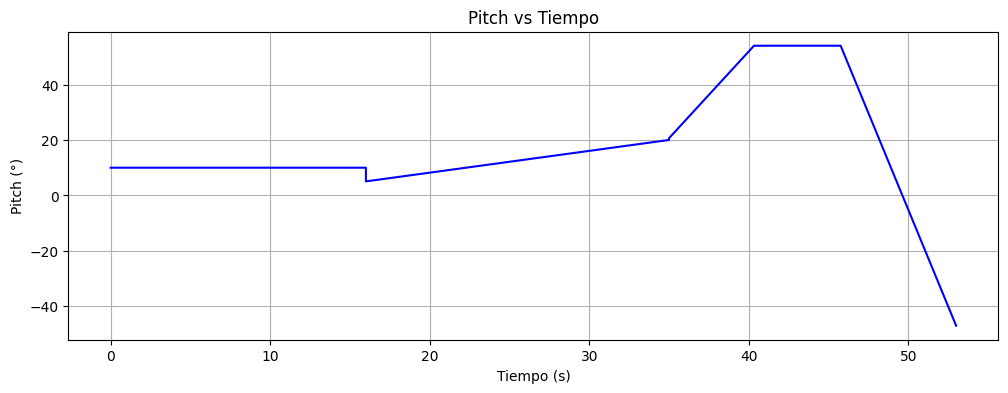

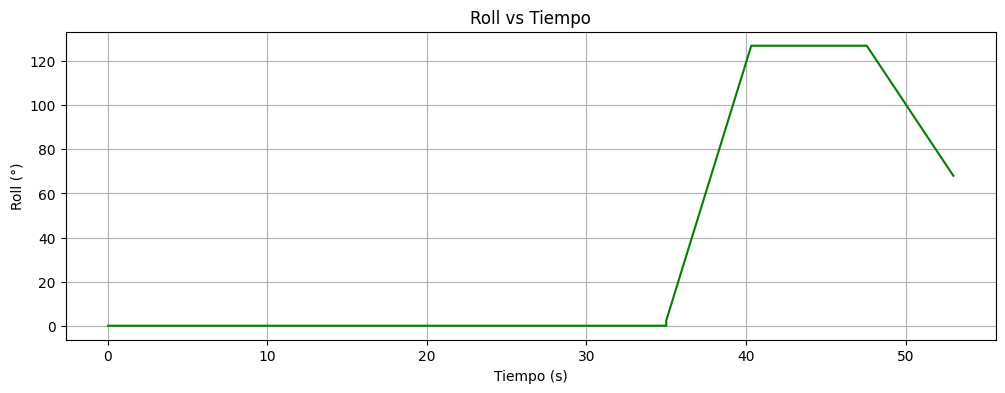

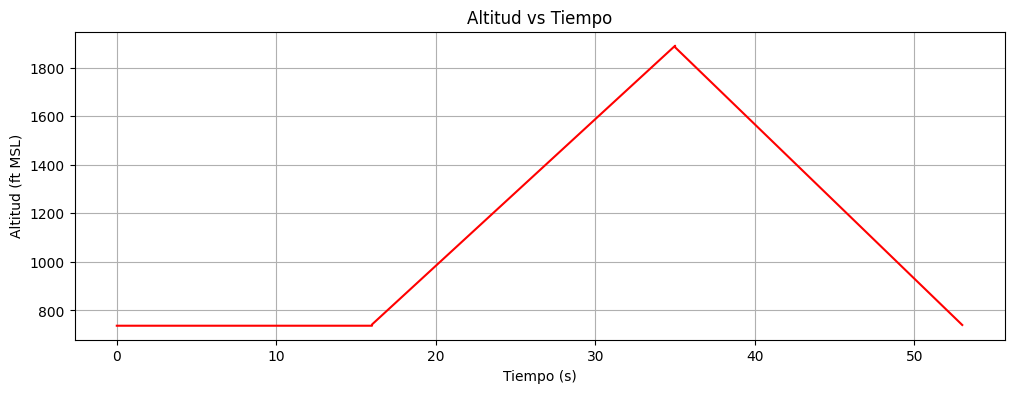

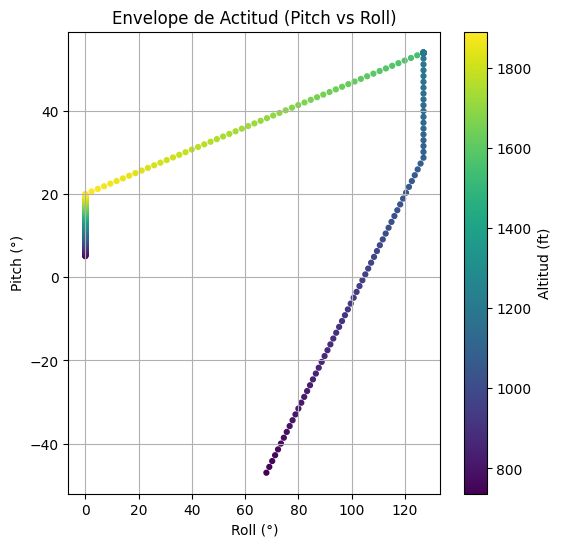

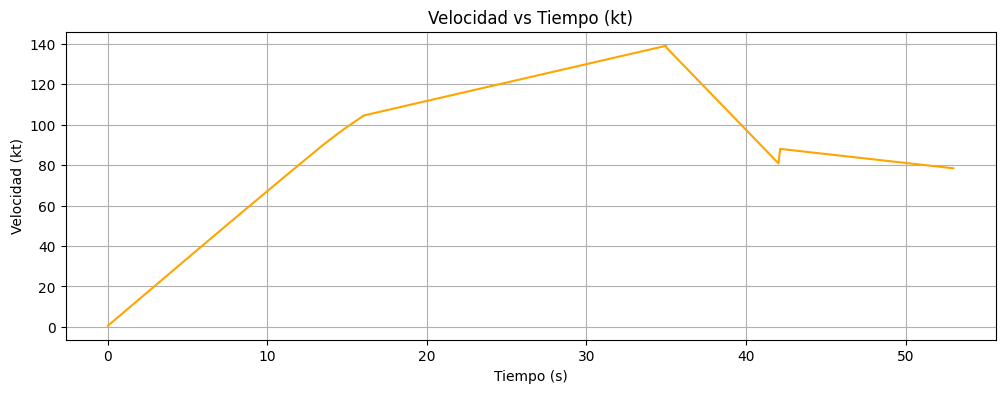

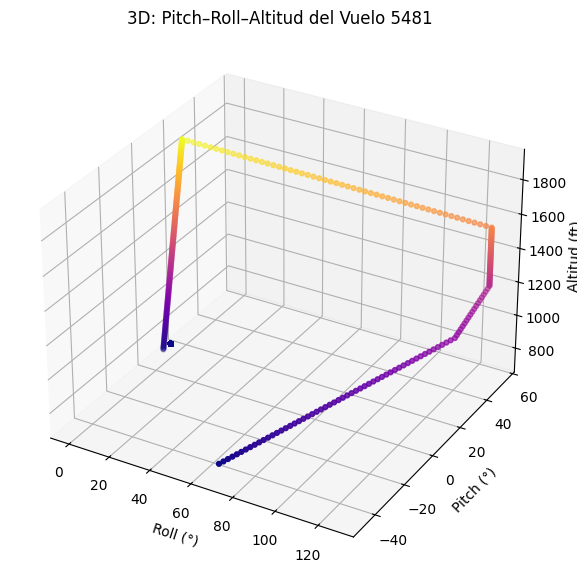

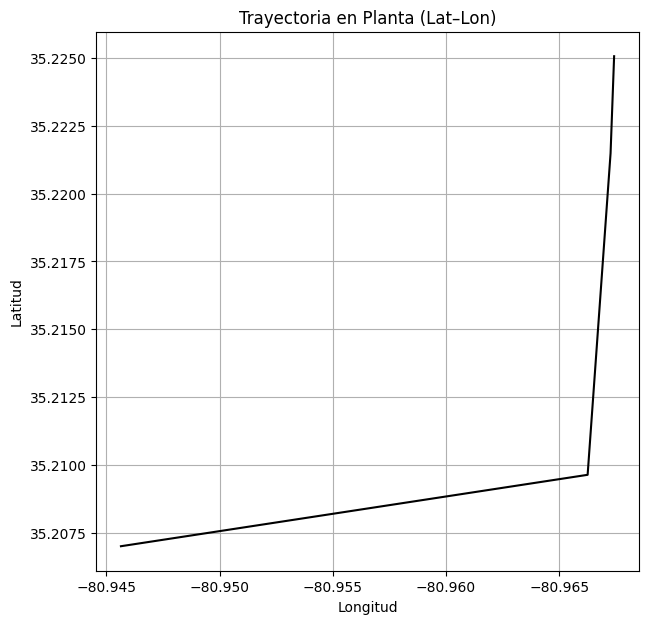

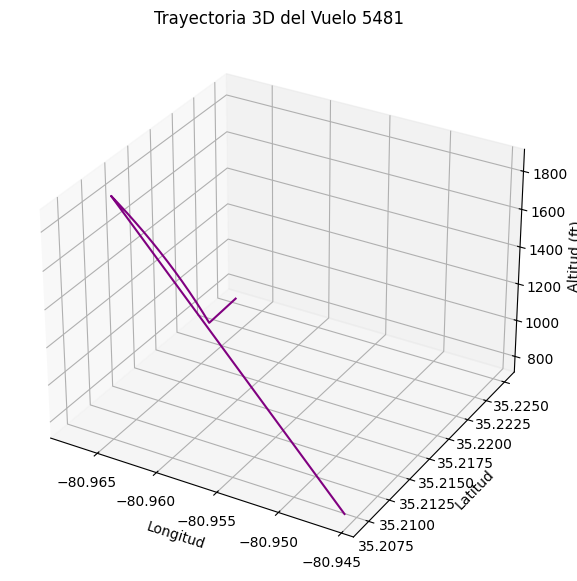

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ====================================
# Cargar CSV (el mismo que ya usaste)
# ====================================
df = pd.read_csv("/content/air_midwest_5481_sim.csv")

# Normalizar encabezados
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("\ufeff","")

# Asegurar numeric
for col in ["time_s", "altitude_ft", "velocity_mps", "pitch_deg", "roll_deg", "heading_deg"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ====================================
# 1) Pitch vs Tiempo
# ====================================
plt.figure(figsize=(12,4))
plt.plot(df["time_s"], df["pitch_deg"], color="blue")
plt.title("Pitch vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Pitch (°)")
plt.grid(True)
plt.show()

# ====================================
# 2) Roll vs Tiempo
# ====================================
plt.figure(figsize=(12,4))
plt.plot(df["time_s"], df["roll_deg"], color="green")
plt.title("Roll vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Roll (°)")
plt.grid(True)
plt.show()

# ====================================
# 3) Altitud vs Tiempo
# ====================================
plt.figure(figsize=(12,4))
plt.plot(df["time_s"], df["altitude_ft"], color="red")
plt.title("Altitud vs Tiempo")
plt.xlabel("Tiempo (s)")
plt.ylabel("Altitud (ft MSL)")
plt.grid(True)
plt.show()

# ====================================
# 4) Envelope de actitud: Pitch–Roll
# ====================================
plt.figure(figsize=(6,6))
plt.scatter(df["roll_deg"], df["pitch_deg"], c=df["altitude_ft"], cmap="viridis", s=12)
plt.title("Envelope de Actitud (Pitch vs Roll)")
plt.xlabel("Roll (°)")
plt.ylabel("Pitch (°)")
plt.colorbar(label="Altitud (ft)")
plt.grid(True)
plt.show()

# ====================================
# 5) Velocidad vs Tiempo
# ====================================

df["velocity_kt"] = df["velocity_mps"] * 1.94384

plt.figure(figsize=(12,4))
plt.plot(df["time_s"], df["velocity_kt"], color="orange")
plt.title("Velocidad vs Tiempo (kt)")
plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad (kt)")
plt.grid(True)
plt.show()


# ====================================
# 6) Gráfico 3D Pitch–Roll–Altitud
# ====================================
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(df["roll_deg"], df["pitch_deg"], df["altitude_ft"],
           c=df["altitude_ft"], cmap="plasma", s=12)

ax.set_title("3D: Pitch–Roll–Altitud del Vuelo 5481")
ax.set_xlabel("Roll (°)")
ax.set_ylabel("Pitch (°)")
ax.set_zlabel("Altitud (ft)")
plt.show()

# ====================================
# 7) Trayectoria 2D (Lat–Lon)
# ====================================
plt.figure(figsize=(7,7))
plt.plot(df["longitude"], df["latitude"], color="black")
plt.title("Trayectoria en Planta (Lat–Lon)")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.gca().invert_xaxis()  # Google Earth usa longitudes invertidas
plt.show()

# ====================================
# 8) Trayectoria 3D (Lat–Lon–Altitud)
# ====================================
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection="3d")

ax.plot(df["longitude"], df["latitude"], df["altitude_ft"], color="purple")

ax.set_title("Trayectoria 3D del Vuelo 5481")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_zlabel("Altitud (ft)")
plt.show()